In [14]:
import numpy as np 
import pandas as pd 
import scipy.stats as stats 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

 

In [47]:
df = pd.read_csv(r'C:\Desktop\Anamika\ML0to1\Datasets\titanic.csv' , usecols = ['Age', 'Fare', 'Survived'])

In [48]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [52]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())

In [53]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [54]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0:1]

In [61]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state= 42)

Text(0.5, 1.0, 'Age QQ plot')

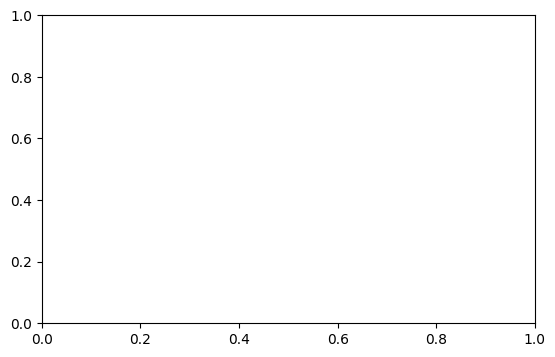

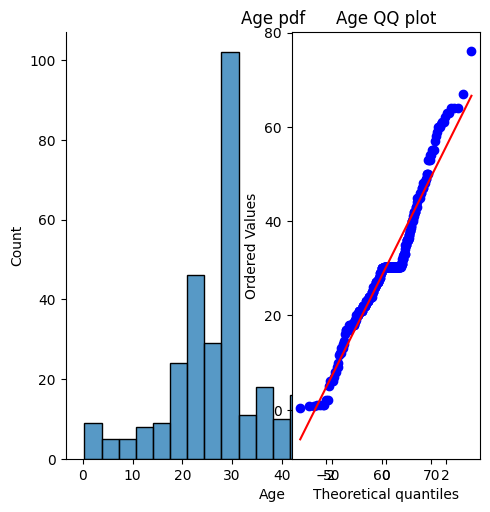

In [62]:
plt.figure(figsize= (14,4))
plt.subplot(121)
sns.displot(X_train['Age'])
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'], dist = 'norm', plot=plt)
plt.title('Age QQ plot')

Text(0.5, 1.0, 'Age QQ plot')

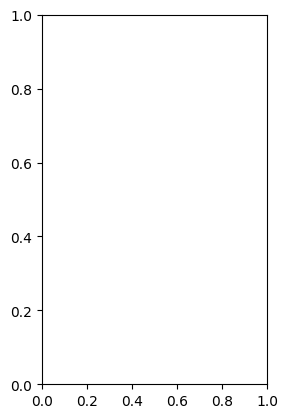

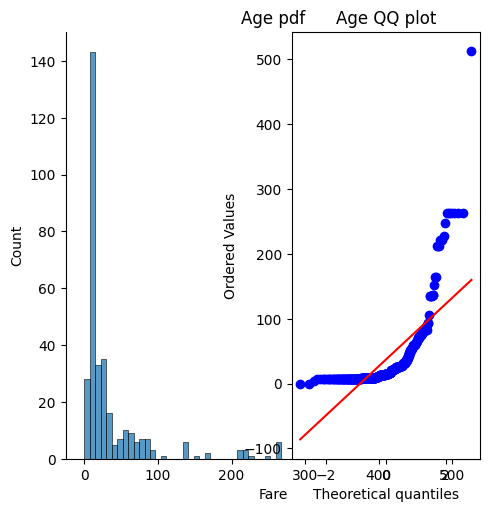

In [63]:
plt.subplot(121)
sns.displot(X_train['Fare'])
plt.title('Age pdf')


plt.subplot(122)
stats.probplot(X_train['Fare'], dist = 'norm', plot=plt)
plt.title('Age QQ plot')

In [64]:
trf = FunctionTransformer(func=np.log1p)

X_train_trans = trf.fit_transform(X_train)
X_test_trans = trf.fit_transform(X_test)

In [65]:
clf = LogisticRegression()
clf1 = DecisionTreeClassifier()

In [66]:
clf.fit(X_train_trans, y_train)

c:\Users\ganam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [67]:
clf1.fit(X_train_trans, y_train)

DecisionTreeClassifier()

In [74]:
y_lr = clf.predict(X_test_trans)
y_dt = clf1.predict(X_test_trans)

In [75]:
print("Accuracy for logistic : ", accuracy_score(y_test,y_lr))
print("Accuracy for decision trees : ", accuracy_score(y_test,y_dt))

Accuracy for logistic :  0.6190476190476191
Accuracy for decision trees :  0.5595238095238095


In [78]:
x_transformed = trf.fit_transform(X)

print("LR", np.mean(cross_val_score(clf, x_transformed, y, scoring='accuracy', cv = 10)))
print("DT", np.mean(cross_val_score(clf1, x_transformed, y, scoring='accuracy', cv = 10)))

LR 0.6556329849012775
DT 0.6004645760743321


c:\Users\ganam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ganam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ganam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ganam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataC